In [ ]:
# ============================================================================
# IMPORTS & CONFIG
# ============================================================================

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import geopandas as gpd
import numpy as np


In [ ]:
# ============================================================================
# Chargement & Préparation des données
# ============================================================================

bornes = pd.read_csv("../data/raw/BornesPropres.csv", low_memory=False) 
vehicules = pd.read_csv("../data/raw/voitures_par_commune_cleaned.csv", low_memory=False)
population = pd.read_csv("../data/clean/population_with_geopoint.csv", low_memory=False)

# dates et types
bornes["date_mise_en_service"] = pd.to_datetime(bornes["date_mise_en_service"], errors="coerce")

vehicules["code_commune"] = vehicules["code_commune"].astype(str).str.zfill(5)  # code commune sur 5 chiffres
vehicules["date_recensement"] = pd.to_datetime(vehicules["date_recensement"], errors="coerce") # date
vehicules["departement"] = vehicules["departement"].astype(str).str.strip().str.upper() # departement
vehicules["nb_voit_elec"] = pd.to_numeric(vehicules["nb_voit_elec"], errors="coerce") # nb voitures elec
vehicules["nb_voit_total"] = pd.to_numeric(vehicules["nb_voit_total"], errors="coerce") # nb voitures

# population
population["departement"] = population["Département"].astype(str).str.strip().str.upper() # departement

cols_to_num = [
    "0 à 19 ans", "20 à 39 ans", "40 à 59 ans",
    "60 à 74 ans", "75 ans et plus", "Total"
]

for col in cols_to_num:
    population[col] = (
        population[col]
        .astype(str)                              # force en string pour nettoyage
        .str.replace(r"\s", "", regex=True)       # supprime tous les espaces
        .str.replace(",", ".", regex=False)       # remplace les virgules par des points si besoin
        .replace({"-": None, "nc": None})         # gère les valeurs non numériques
        .astype(float)                            # convertit en float
    )


# Nouvelles colonnes dates (annee, mois, jour)
def extraire_date_datetime(df, colonne_date, prefix=""):
    """
    Crée des colonnes 'annee', 'mois', 'jour' en type datetime.date à partir d'une colonne datetime.
    prefix : préfixe pour les nouvelles colonnes
    """
    col_prefix = f"_{prefix}" if prefix else ""
    df[f'annee{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.year.astype('Int64')
    df[f'mois{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.month.astype('Int64')
    df[f'jour{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.day.astype('Int64')
    df[f'date{col_prefix}'] = pd.to_datetime(df[colonne_date]).dt.date  # version date
    return df

# Application aux bornes et véhicules
bornes = extraire_date_datetime(bornes, 'date_mise_en_service', prefix='mes')
vehicules = extraire_date_datetime(vehicules, 'date_recensement', prefix='recensement')

# Visualisation
# print(bornes.dtypes)
# print(vehicules.dtypes)

In [ ]:
# ============================================================================
# Jointure VEHICULES & POPULATION
# ============================================================================

# Vérifier les départements communs
set_pop = set(population['departement'].unique())
set_vehicules = set(vehicules['departement'].unique())

# Visualiser
print("Départements communs population / véhicules :", len(set_pop & set_vehicules))


# Effectuer la jointure
vehicule_pop = vehicules.merge(
    population,
    on='departement',
    how='inner'  # inner = seulement les départements présents dans les deux jeux
)

# Visualisation
# print(vehicule_pop.head())

In [ ]:
# ============================================================================
# Jointure BORNES & POPULATION
# ============================================================================

# --- Nettoyage BORNES ---

# Création GeoDataFrames en WGS84
gdf_bornes = gpd.GeoDataFrame(
    bornes,
    geometry=gpd.points_from_xy(bornes['consolidated_longitude'], bornes['consolidated_latitude']),
    crs="EPSG:4326"
)

gdf_population = gpd.GeoDataFrame(
    population,
    geometry=gpd.points_from_xy(population['longitude_decimal'], population['latitude_decimal']),
    crs="EPSG:4326"
)

# Reprojection dans Lambert 93 (mètres) pour distance en mètres
gdf_bornes = gdf_bornes.to_crs(2154)
gdf_population = gdf_population.to_crs(2154)


# ---  Jointure par proximité ---
bornes_pop = gpd.sjoin_nearest(
    gdf_bornes,
    gdf_population,
    how='left',
    max_distance=60000,
    rsuffix='_pop'  # suffixe ajouté pour les colonnes du gdf_population
)

# Visualisation
# print(bornes_pop.columns)
# print(bornes_pop['departement'].head())

In [ ]:
# --- Diagnostic : bornes sans correspondance ---
bornes_sans_pop = bornes_pop[bornes_pop['Total'].isna()]

print(f"Bornes totales : {len(bornes_pop)}")
print(f"Bornes sans correspondance : {len(bornes_sans_pop)} "
      f"({len(bornes_sans_pop)/len(bornes_pop)*100:.1f}%)")

# Extraction des coordonnées x et y depuis la colonne geometry
bornes_sans_pop = bornes_sans_pop.assign(
    x=bornes_sans_pop.geometry.x,
    y=bornes_sans_pop.geometry.y
)

# Visualisation
# print("\nAperçu des bornes sans correspondance :")
# print(bornes_sans_pop[['x', 'y']].head())

In [ ]:
# ============================================================================  
# Indicateurs mensuels PDC par station (version corrigée)
# ============================================================================

# --- Création d'une colonne année-mois au format YYYY-MM
bornes_pop['annee_mois'] = bornes_pop['annee_mes'].astype(str) + '-' + bornes_pop['mois_mes'].astype(str).str.zfill(2)

# --- Aggréger le nombre de PDC par station et par mois
stations_mois = bornes_pop.groupby(['id_station_local', 'annee_mois']).agg(
    nbre_pdc_station=('nbre_pdc', 'sum')
).reset_index()

# --- Indicateurs mensuels par mois
indicateurs_stations = stations_mois.groupby('annee_mois').agg(
    nouvelles_stations=('id_station_local', 'nunique')  # nouvelles stations uniques par mois
).reset_index()

# --- Cumul des stations
indicateurs_stations['stations_cumulees'] = indicateurs_stations['nouvelles_stations'].cumsum()

# --- Nombre total de PDC cumulées
indicateurs_stations['pdc_cumulees'] = stations_mois.groupby('annee_mois')['nbre_pdc_station'].sum().cumsum().values

# --- Tri par période
indicateurs_stations = indicateurs_stations.sort_values('annee_mois').reset_index(drop=True)

# --- Visualisation
#print(indicateurs_stations.head())


In [ ]:
# ============================================================================
# Gestion des données cumulées dans vehicules_pop
# ============================================================================

# Dernier relevé de chaque commune pour chaque année
vehicule_pop_last = (
    vehicule_pop.sort_values(['id_unique_commune', 'date_recensement'])
                .groupby(['id_unique_commune', 'annee_recensement'])
                .last()
                .reset_index()
)

# Dernier relevé de chaque commune pour chaque mois
vehicule_pop_last_month = (
    vehicule_pop.sort_values(['id_unique_commune', 'date_recensement'])
                .groupby(['id_unique_commune', 'annee_recensement', 'mois_recensement'])
                .last()
                .reset_index()
)

# Visualisation
# print(vehicule_pop_last.head())
# print(vehicule_pop_last_month.head())


# Agrégation des VE au niveau départemental
ve_par_dep = vehicule_pop_last.groupby('departement')['nb_voit_elec'].sum().reset_index()

# Agrégation des VT au niveau départemental
ve_par_dep_total = vehicule_pop_last.groupby('departement')['nb_voit_total'].sum().reset_index()

# Visualisation
# print(ve_par_dep.head())
# print(ve_par_dep_total.head())


# KPI VE annuel 
kpi_ve_annuel = vehicule_pop_last.groupby('annee_recensement').agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_voitures=('nb_voit_total', 'sum')
).reset_index()

# KPI VE mensuel 
kpi_ve_mensuel = vehicule_pop_last_month.groupby(['annee_recensement','mois_recensement']).agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_voitures=('nb_voit_total', 'sum')
).reset_index()

# Visualisation
# print(kpi_ve_annuel.head())
# print(kpi_ve_mensuel.head())

In [ ]:
# ============================================================================
# CUMUL DES PDC PAR STATIONS ET DEPARTEMENT
# ============================================================================

# --- Dernière date dispo par station et département ---
stations_last = (
    bornes_pop.drop_duplicates(subset=['id_station_local', 'departement'])
)

# --- Nombre de stations par département ---
stations_par_dep = stations_last.groupby('departement')['id_station_local'].nunique().reset_index()
stations_par_dep.rename(columns={'id_station_local': 'nb_stations'}, inplace=True)

# --- Nombre total de PDC par département ---
pdc_par_dep = bornes_pop.groupby('departement')['nbre_pdc'].sum().reset_index()

# --- Véhicules et population ---
vehicules_last = (
    vehicule_pop.sort_values('date_recensement')
    .groupby('departement')
    .tail(1)
)
ve_par_dep = vehicules_last.groupby('departement')['nb_voit_elec'].sum().reset_index()

# --- Fusion ---
df_correlations = (
    stations_par_dep
    .merge(pdc_par_dep, on='departement', how='left')
    .merge(ve_par_dep, on='departement', how='left')
    .merge(population, on='departement', how='left')
)

# --- Indicateurs par 1000 habitants ---
df_correlations['stations_pour_1000_hab'] = df_correlations['nb_stations'] / df_correlations['Total'] * 1000
df_correlations['pdc_pour_1000_hab'] = df_correlations['nbre_pdc'] / df_correlations['Total'] * 1000

# Visualisation
# df_correlations[['departement','nb_stations','nbre_pdc','nb_voit_elec','Total','stations_pour_1000_hab','pdc_pour_1000_hab']].head()


In [ ]:
# ============================================================================ 
# Stations & PDC / 1000 hab : agrégation mensuelle des données par département
# ============================================================================

# Convertir dates
vehicule_pop['date_recensement'] = pd.to_datetime(vehicule_pop['date_recensement'], errors='coerce')
bornes_pop['date_mise_en_service'] = pd.to_datetime(bornes_pop['date_mise_en_service'], errors='coerce')

# Ajouter colonne année-mois
bornes_pop['annee_mois'] = bornes_pop['date_mise_en_service'].dt.to_period('M')
vehicule_pop['annee_mois'] = vehicule_pop['date_recensement'].dt.to_period('M')

# Filtrer pour les dates à partir de 2020
bornes_pop = bornes_pop[bornes_pop['annee_mois'] >= '2020-01']
vehicule_pop = vehicule_pop[vehicule_pop['annee_mois'] >= '2020-01']

# Agrégation par station & mois
stations_mois = bornes_pop.groupby(['id_station_local','departement','annee_mois']).agg(
    nbre_pdc_station=('nbre_pdc','sum')
).reset_index()

# Nombre de stations par département & mois
stations_par_dep_mois = stations_mois.groupby(['departement','annee_mois'])['id_station_local'].nunique().reset_index()
stations_par_dep_mois.rename(columns={'id_station_local':'nb_stations'}, inplace=True)

# Nombre total de PDC par département & mois
pdc_par_dep_mois = stations_mois.groupby(['departement','annee_mois'])['nbre_pdc_station'].sum().reset_index()
pdc_par_dep_mois.rename(columns={'nbre_pdc_station':'nbre_pdc'}, inplace=True)

# Véhicules par département & mois
vehicules_last_month = (
    vehicule_pop.sort_values('date_recensement')
    .groupby(['departement','annee_mois'])
    .tail(1)
)
ve_par_dep_mois = vehicules_last_month.groupby(['departement','annee_mois'])['nb_voit_elec'].sum().reset_index()

# Fusion avec population
df_mensuel = (
    stations_par_dep_mois
    .merge(pdc_par_dep_mois, on=['departement','annee_mois'], how='left')
    .merge(ve_par_dep_mois, on=['departement','annee_mois'], how='left')
    .merge(population, on='departement', how='left')
)

# Remplacer les NaN de VE par 0 si nécessaire
# df_mensuel['nb_voit_elec'] = df_mensuel['nb_voit_elec'].fillna(0)

# Calcul indicateurs pour 1000 habitants
df_mensuel['stations_pour_1000_hab'] = df_mensuel['nb_stations'] / df_mensuel['Total'] * 1000
df_mensuel['pdc_pour_1000_hab'] = df_mensuel['nbre_pdc'] / df_mensuel['Total'] * 1000

# Tri final
df_mensuel = df_mensuel.sort_values(['departement','annee_mois']).reset_index(drop=True)

# Visualisation
# print(df_mensuel.head(10))


In [ ]:
# ============================================================================ 
# Stations & PDC / 1000 hab : agrégation annuelle des données par département
# ============================================================================

# Ajouter colonne année
bornes_pop['annee'] = bornes_pop['date_mise_en_service'].dt.year
vehicule_pop['annee'] = vehicule_pop['date_recensement'].dt.year

# Agrégation par station pour l'année
stations_annee = bornes_pop.groupby(['id_station_local', 'departement', 'annee']).agg(
    nbre_pdc_station=('nbre_pdc','sum')
).reset_index()

# Nombre de stations par département et année
stations_par_dep = stations_annee.groupby(['departement','annee'])['id_station_local'].nunique().reset_index()
stations_par_dep.rename(columns={'id_station_local':'nb_stations'}, inplace=True)

# Nombre total de PDC par département et année
pdc_par_dep = stations_annee.groupby(['departement','annee'])['nbre_pdc_station'].sum().reset_index()
pdc_par_dep.rename(columns={'nbre_pdc_station':'nbre_pdc'}, inplace=True)

# Véhicules par département et année (dernière date dispo)
vehicules_last = (
    vehicule_pop.sort_values('date_recensement')
    .groupby(['departement','annee'])
    .tail(1)
)
ve_par_dep = vehicules_last.groupby(['departement','annee'])['nb_voit_elec'].sum().reset_index()

# Fusion avec population
df_correlations = (
    stations_par_dep
    .merge(pdc_par_dep, on=['departement','annee'], how='left')
    .merge(ve_par_dep, on=['departement','annee'], how='left')
    .merge(population, on='departement', how='left')
)

# Calcul indicateurs pour 1000 habitants
df_correlations['stations_pour_1000_hab'] = df_correlations['nb_stations'] / df_correlations['Total'] * 1000
df_correlations['pdc_pour_1000_hab'] = df_correlations['nbre_pdc'] / df_correlations['Total'] * 1000

# Tri final
df_correlations = df_correlations.sort_values(['departement','annee']).reset_index(drop=True)

# Visualisation
# print(df_correlations[['departement','annee','nb_stations','nbre_pdc','nb_voit_elec',
#                        'Total','stations_pour_1000_hab','pdc_pour_1000_hab']].head())


In [ ]:
# ============================================================================ 
# 📊 KPI GÉNÉRAUX – PARC ET INFRASTRUCTURES
# ============================================================================

print("\n" + "="*50)
print("📊 KPI GÉNÉRAUX")
print("="*50)

# --- Totaux VE / VT ---
nb_vt_total = vehicule_pop['nb_voit_total'].sum()
nb_ve_total = vehicule_pop['nb_voit_elec'].sum()
pct_ve_vs_vt = (nb_ve_total / nb_vt_total * 100) if nb_vt_total else 0

print(f"🚗 Total VT en 2025 : {nb_vt_total:,} VT")
print(f"🔢 Total VE en 2025 : {nb_ve_total:,} VE")
print(f"📊 Les VE représentent {pct_ve_vs_vt:.1f}% du parc total de véhicules")

# --- Nombre de bornes et ratio VE ---
nb_bornes = bornes_pop['id_station_local'].nunique() if 'id_station_local' in bornes_pop else len(bornes_pop)
ratio_bornes_ve = nb_bornes / nb_ve_total if nb_ve_total else 0
ratio_pour_10_ve = ratio_bornes_ve * 10

print(f"🔌 Nombre total de bornes : {nb_bornes:,}")
print(f"⚡ Ratio bornes / VE : {ratio_bornes_ve:.3f} "
      f"(soit {ratio_pour_10_ve:.1f} bornes pour 10 VE)")
print("✅ Objectif AFI atteint" if ratio_pour_10_ve >= 1 else f"❌ Déficit : {1 - ratio_pour_10_ve:.1f} borne(s) manquante(s) pour 10 VE")

# --- Densité moyenne bornes / population ---
bornes_par_dep = bornes_pop.groupby("departement")['id_station_local'].nunique().reset_index(name="nb_bornes")
pop_par_dep = population.groupby("departement")["Total"].sum().reset_index(name="population")
df_dep = bornes_par_dep.merge(pop_par_dep, on="departement", how="left")
df_dep["bornes_pour_1000_hab"] = (df_dep["nb_bornes"] / df_dep["population"]) * 1000
print(f"🏘️  Densité moyenne : {df_dep['bornes_pour_1000_hab'].mean():.2f} bornes pour 1000 habitants")


In [ ]:
# ============================================================================ 
# 📊 ÉVOLUTION DU PARC VE & VT PAR AN
# ============================================================================

print("\n" + "="*50)
print("📊 ÉVOLUTION DU PARC VE & VT PAR AN")
print("="*50)

vehicule_pop['date_recensement'] = pd.to_datetime(vehicule_pop['date_recensement'])
vehicule_pop['annee'] = vehicule_pop['date_recensement'].dt.year

dernieres_dates_dep = vehicule_pop.groupby(['annee', 'departement'])['date_recensement'].max().reset_index()
vehicule_latest = vehicule_pop.merge(dernieres_dates_dep, on=['annee','departement','date_recensement'], how='inner')

cumul_vehicules_annuel = vehicule_latest.groupby('annee').agg(
    total_ve=('nb_voit_elec', 'sum'),
    total_vt=('nb_voit_total', 'sum')
).reset_index()

# Croissance annuelle
cumul_vehicules_annuel['croissance_ve_%'] = cumul_vehicules_annuel['total_ve'].pct_change() * 100
cumul_vehicules_annuel['croissance_vt_%'] = cumul_vehicules_annuel['total_vt'].pct_change() * 100
cumul_vehicules_annuel['nouvelles_immats_ve'] = cumul_vehicules_annuel['total_ve'].diff()

# Affichage
print("\n🚗 Cumul annuel des véhicules électriques et totaux :")
print(cumul_vehicules_annuel[['annee','total_ve','total_vt']].to_string(index=False))

print("\n📈 Croissance annuelle (%) :")
print(cumul_vehicules_annuel[['annee','croissance_ve_%','croissance_vt_%']].to_string(index=False))

annee_record_ve = cumul_vehicules_annuel.loc[cumul_vehicules_annuel['nouvelles_immats_ve'].idxmax(),'annee']
print(f"\n🏆 Année record en immatriculations VE : {annee_record_ve}")


In [ ]:
# ============================================================================ 
# 📊 ÉVOLUTION PARC VE & INFRASTRUCTURES
# ============================================================================

print("\n" + "="*50)
print("📊 ÉVOLUTION PARC VE & INFRASTRUCTURES")
print("="*50)

croissance_ve = (vehicule_pop.loc[vehicule_pop['annee']==vehicule_pop['annee'].max(),'nb_voit_elec'].sum() -
                 vehicule_pop.loc[vehicule_pop['annee']==vehicule_pop['annee'].min(),'nb_voit_elec'].sum()) / \
                vehicule_pop.loc[vehicule_pop['annee']==vehicule_pop['annee'].min(),'nb_voit_elec'].sum() * 100
print(f"🚗 Évolution du parc VE : {croissance_ve:,.1f} %")

croissance_pdc = (pdc_par_dep_mois.loc[pdc_par_dep_mois['annee_mois']==pdc_par_dep_mois['annee_mois'].max(),'nbre_pdc'].sum() -
                  pdc_par_dep_mois.loc[pdc_par_dep_mois['annee_mois']==pdc_par_dep_mois['annee_mois'].min(),'nbre_pdc'].sum()) / \
                 pdc_par_dep_mois.loc[pdc_par_dep_mois['annee_mois']==pdc_par_dep_mois['annee_mois'].min(),'nbre_pdc'].sum() * 100
print(f"🔌 Évolution du nombre de PDC : {croissance_pdc:,.1f} % {'✅' if croissance_pdc>0 else '❌'}")

pdc_diff = pdc_par_dep_mois.groupby('annee_mois')['nbre_pdc'].sum().diff().reset_index(name='nouvelles_pdc')
mois_record_pdc = pdc_diff.loc[pdc_diff['nouvelles_pdc'].idxmax(),'annee_mois']
print(f"📅 Mois record de déploiement PDC : {mois_record_pdc}")

# Ratio PDC / VE
pdc_total_actuel = pdc_par_dep_mois.loc[pdc_par_dep_mois['annee_mois']==pdc_par_dep_mois['annee_mois'].max(),'nbre_pdc'].sum()
ve_total_actuel = vehicule_pop.loc[vehicule_pop['annee']==vehicule_pop['annee'].max(),'nb_voit_elec'].sum()
print(f"⚡ Ratio PDC/VE actuel : {pdc_total_actuel/ve_total_actuel:.3f}")

# Disparités territoriales
print("\n🏘️ Disparités territoriales")

# Top / Flop 3 PDC
pdc_hab = pdc_par_dep_mois.groupby('departement')['nbre_pdc'].max().reset_index()
pdc_hab = pdc_hab.merge(population[['departement','Total']], on='departement')
pdc_hab['pdc_pour_1000_hab'] = (pdc_hab['nbre_pdc']/pdc_hab['Total'])*1000

print("🔝 Top 3 départements (PDC/1000 hab) :")
for _, row in pdc_hab.nlargest(3,'pdc_pour_1000_hab').iterrows():
    print(f"   - {row['departement']}: {row['pdc_pour_1000_hab']:.2f}")

print("🔻 Flop 3 départements (PDC/1000 hab) :")
for _, row in pdc_hab.nsmallest(3,'pdc_pour_1000_hab').iterrows():
    print(f"   - {row['departement']}: {row['pdc_pour_1000_hab']:.2f}")

# Top / Flop 3 Bornes
bornes_hab = stations_par_dep_mois.groupby('departement')['nb_stations'].max().reset_index()
bornes_hab = bornes_hab.merge(population[['departement','Total']], on='departement')
bornes_hab['bornes_pour_1000_hab'] = (bornes_hab['nb_stations']/bornes_hab['Total'])*1000

print("\n🔝 Top 3 départements (Bornes/1000 hab) :")
for _, row in bornes_hab.nlargest(3,'bornes_pour_1000_hab').iterrows():
    print(f"   - {row['departement']}: {row['bornes_pour_1000_hab']:.2f}")

print("🔻 Flop 3 départements (Bornes/1000 hab) :")
for _, row in bornes_hab.nsmallest(3,'bornes_pour_1000_hab').iterrows():
    print(f"   - {row['departement']}: {row['bornes_pour_1000_hab']:.2f}")

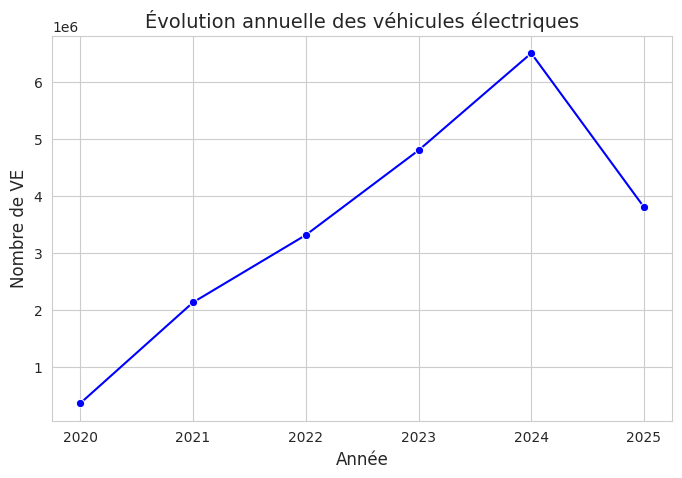

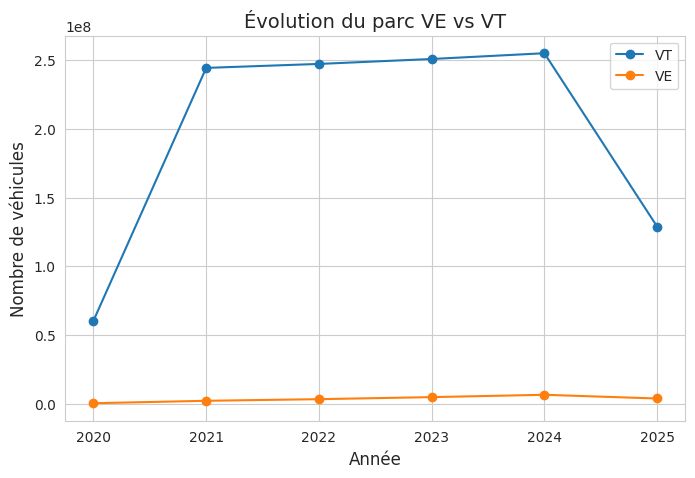

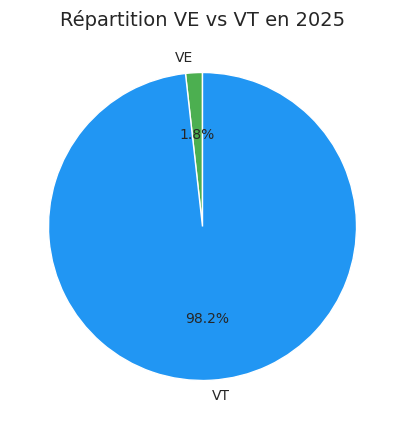

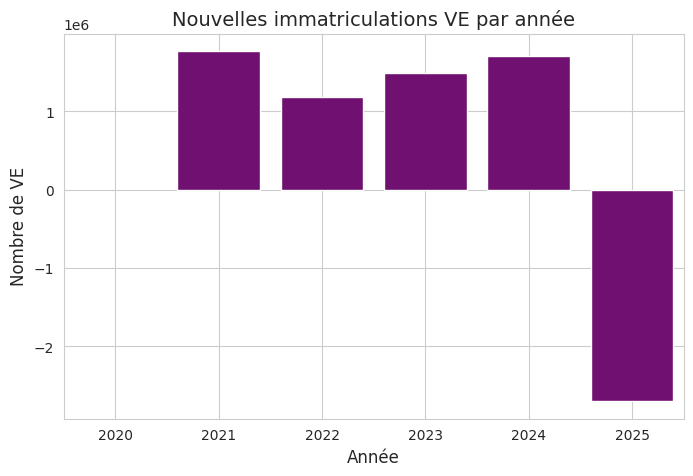

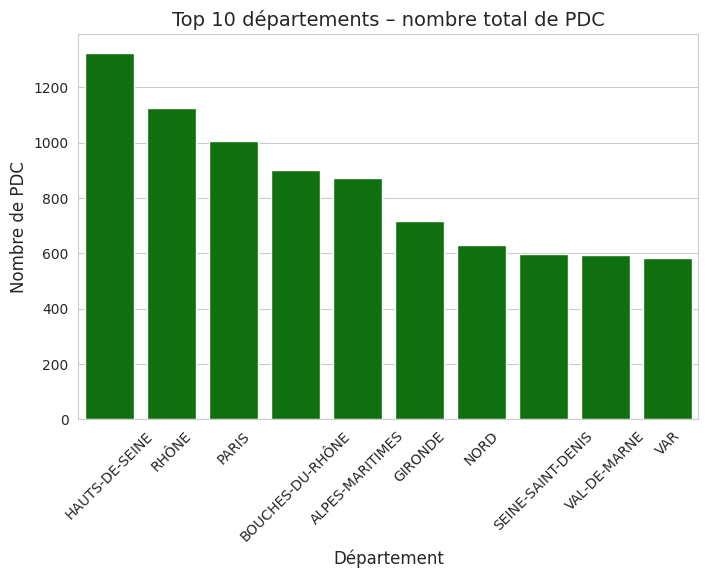

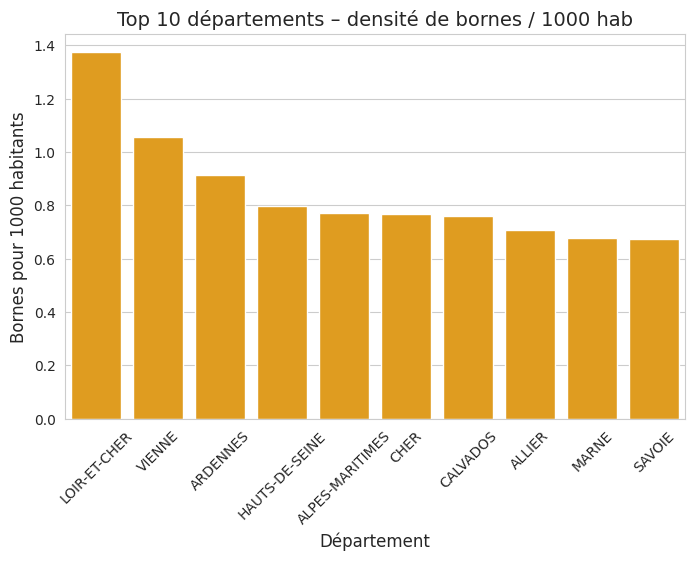

In [287]:
# ============================================================================ 
# 3. GRAPHS
# ============================================================================

# --- Assurer uniformité esthétique ---
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (8,5), 'axes.titlesize':14, 'axes.labelsize':12})

# ===================================================================
# 0️⃣ Préparation des colonnes nécessaires
# ===================================================================
# Création colonne 'annee' pour vehicule_pop
if 'annee' not in vehicule_pop.columns:
    vehicule_pop['annee'] = pd.to_datetime(vehicule_pop['date_recensement']).dt.year

# Création colonne 'annee' pour pdc_par_dep_mois
if 'annee' not in pdc_par_dep_mois.columns and 'annee_mes' in pdc_par_dep_mois.columns:
    pdc_par_dep_mois['annee'] = pdc_par_dep_mois['annee_mes']

# ===================================================================
# 1️⃣ Evolution annuelle du parc VE
# ===================================================================
df_ve_annee = vehicule_pop.groupby('annee')['nb_voit_elec'].sum().reset_index()

plt.figure()
sns.lineplot(data=df_ve_annee, x='annee', y='nb_voit_elec', marker='o', color='blue')
plt.title("Évolution annuelle des véhicules électriques")
plt.ylabel("Nombre de VE")
plt.xlabel("Année")
plt.grid(True)
plt.show()

# ===================================================================
# 2️⃣ Parc VE vs VT
# ===================================================================
cumul_vehicules_annuel = vehicule_pop.groupby('annee').agg(
    total_ve=('nb_voit_elec','sum'),
    total_vt=('nb_voit_total','sum')
).reset_index()

plt.figure()
plt.plot(cumul_vehicules_annuel['annee'], cumul_vehicules_annuel['total_vt'], label='VT', marker='o')
plt.plot(cumul_vehicules_annuel['annee'], cumul_vehicules_annuel['total_ve'], label='VE', marker='o')
plt.title("Évolution du parc VE vs VT")
plt.xlabel("Année")
plt.ylabel("Nombre de véhicules")
plt.legend()
plt.grid(True)
plt.show()

# ===================================================================
# 3️⃣ Répartition VE vs VT (2025)
# ===================================================================
sizes = [nb_ve_total, nb_vt_total - nb_ve_total]
plt.figure()
plt.pie(sizes, labels=['VE','VT'], autopct='%1.1f%%', startangle=90, colors=['#4CAF50','#2196F3'])
plt.title("Répartition VE vs VT en 2025")
plt.show()

# ===================================================================
# 4️⃣ Nouvelles immatriculations VE par année
# ===================================================================
cumul_vehicules_annuel['nouvelles_immats_ve'] = cumul_vehicules_annuel['total_ve'].diff()

plt.figure()
sns.barplot(x='annee', y='nouvelles_immats_ve', data=cumul_vehicules_annuel, color='purple')
plt.title("Nouvelles immatriculations VE par année")
plt.ylabel("Nombre de VE")
plt.xlabel("Année")
plt.grid(True)
plt.show()

# ===================================================================
# 5️⃣ Top 10 départements – nombre total de PDC
# ===================================================================
df_dep_top10_pdc = df_dep.sort_values('nb_bornes', ascending=False).head(10)
plt.figure()
sns.barplot(x='departement', y='nb_bornes', data=df_dep_top10_pdc, color='green')
plt.title("Top 10 départements – nombre total de PDC")
plt.ylabel("Nombre de PDC")
plt.xlabel("Département")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

# ===================================================================
# 6️⃣ Top 10 départements – densité des bornes
# ===================================================================
df_dep_top10 = df_dep.sort_values('bornes_pour_1000_hab', ascending=False).head(10)
plt.figure()
sns.barplot(x='departement', y='bornes_pour_1000_hab', data=df_dep_top10, color='orange')
plt.title("Top 10 départements – densité de bornes / 1000 hab")
plt.ylabel("Bornes pour 1000 habitants")
plt.xlabel("Département")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()



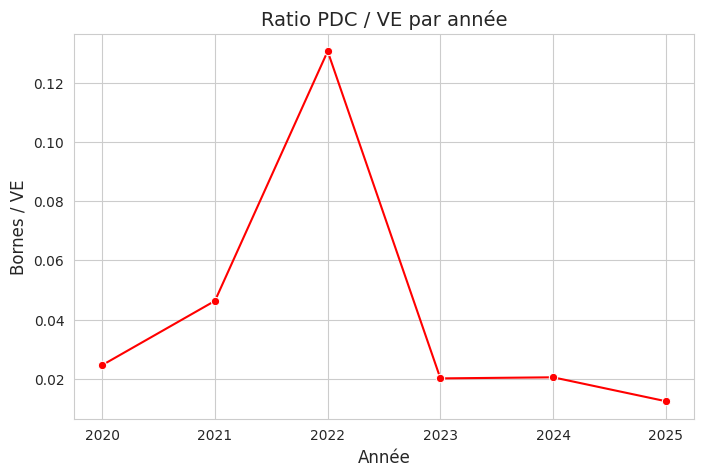

In [ ]:
# ===================================================================
# 7️⃣ Ratio PDC / VE par année
# ===================================================================

# S’assurer que 'annee' est bien int
pdc_par_dep_mois['annee'] = pdc_par_dep_mois['annee_mois'].dt.year.astype(int)

# Somme des PDC par année
pdc_annee = pdc_par_dep_mois.groupby('annee')['nbre_pdc'].sum().reset_index()

# Faire un merge pour aligner VE et PDC sur les mêmes années
df_ratio = pd.merge(
    cumul_vehicules_annuel[['annee','total_ve']],
    pdc_annee,
    on='annee',
    how='inner'
)

# Calcul du ratio PDC / VE
df_ratio['ratio_pdc_ve'] = df_ratio['nbre_pdc'] / df_ratio['total_ve']

# Plot
plt.figure()
sns.lineplot(data=df_ratio, x='annee', y='ratio_pdc_ve', marker='o', color='red')
plt.title("Ratio PDC / VE par année")
plt.ylabel("Bornes / VE")
plt.xlabel("Année")
plt.grid(True)
plt.show()




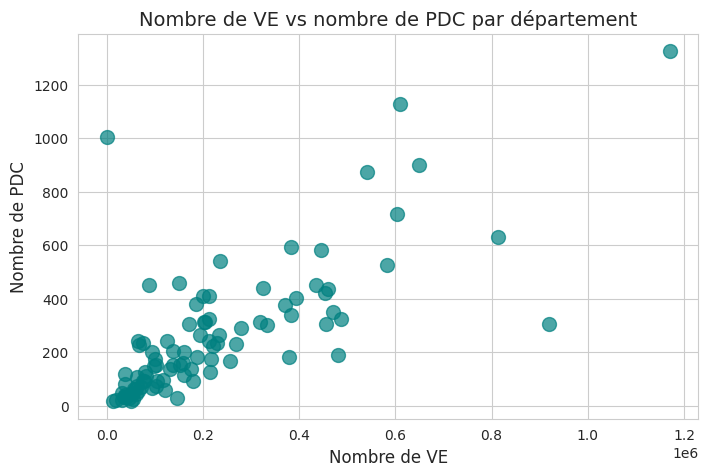

In [ ]:
# ===================================================================
# 8️⃣ Scatter plot VE vs PDC par département
# ===================================================================

# Somme des VE par département
ve_par_dep = vehicule_pop.groupby('departement')['nb_voit_elec'].sum().reset_index()

# Merge avec df_dep pour avoir nb_voit_elec
df_dep_plot = df_dep.merge(ve_par_dep, on='departement', how='left')

plt.figure()
plt.scatter(df_dep_plot['nb_voit_elec'], df_dep_plot['nb_bornes'], s=100, alpha=0.7, color='teal')
plt.title("Nombre de VE vs nombre de PDC par département")
plt.xlabel("Nombre de VE")
plt.ylabel("Nombre de PDC")
plt.grid(True)
plt.show()

❌❌❌ ARCHIVES ❌❌❌

In [ ]:
# ============================================================================ 
# ANALYSE & KPI (original maj) ❌
# ============================================================================

def analyse_automatique(df_ve, df_bornes, df_correlations, freq='M'):
    """
    Génère un texte d'analyse automatique basé sur les données VE, bornes et corrélations.
    df_bornes doit contenir la colonne 'nouvelles_bornes' et 'bornes_cumulees'.
    freq : 'A' pour annuel, 'M' pour mensuel
    """
    # --- 1. Tendances VE ---
    croissance_ve = (df_ve['nb_ve'].iloc[-1] - df_ve['nb_ve'].iloc[0]) / df_ve['nb_ve'].iloc[0] * 100
    annee_max_ve = df_ve.loc[df_ve['nb_ve'].idxmax(), 'annee' if 'annee' in df_ve.columns else 'annee_mois']
    
    # --- 2. Tendances Bornes ---
    croissance_bornes = (df_bornes['bornes_cumulees'].iloc[-1] - df_bornes['bornes_cumulees'].iloc[0]) / df_bornes['bornes_cumulees'].iloc[0] * 100
    # colonne correcte selon freq
    date_col = 'annee' if freq=='A' else 'annee_mois'
    annee_max_bornes = df_bornes.loc[df_bornes['bornes_cumulees'].idxmax(), date_col]
    
    # --- 3. Ratio Bornes/VE ---
    ratio_bornes_ve = df_bornes['bornes_cumulees'].iloc[-1] / df_ve['nb_ve'].iloc[-1]
    
    # --- 4. Corrélation ---
    corr = df_correlations['bornes_pour_1000_hab'].corr(df_correlations['nb_voit_elec'])
    
    # --- 5. Détection des disparités ---
    top_dep = df_correlations.sort_values('bornes_pour_1000_hab', ascending=False).head(3)
    flop_dep = df_correlations.sort_values('bornes_pour_1000_hab', ascending=True).head(3)
    
    # --- 6. Génération du texte ---
    texte = f"""
    📊 **Analyse Automatique - Infrastructures VE en France**

    1️⃣ **Parc de véhicules électriques**
    - Croissance sur la période : **+{croissance_ve:.1f}%**
    - Année record en immatriculations : **{annee_max_ve}**

    2️⃣ **Bornes de recharge**
    - Croissance sur la période : **+{croissance_bornes:.1f}%**
    - Mois/Année record en déploiement : **{annee_max_bornes}**
    - Ratio actuel bornes/VE : **1 borne pour {1/ratio_bornes_ve:.1f} VE**

    3️⃣ **Corrélation**
    - Corrélation bornes ↔ VE : **{corr:.2f}**

    4️⃣ **Disparités territoriales**
    - Top 3 départements (bornes/1000 hab) : {', '.join(top_dep['departement'])}
    - Flop 3 départements : {', '.join(flop_dep['departement'])}
    """
    from IPython.display import Markdown, display
    display(Markdown(texte))
    
    return texte

analyse_text = analyse_automatique(df_ve, bornes_mois, df_correlations, freq='M')